## Cerebellar neuron models, using Brian2

#### Ilaria Carannante
mailto: ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France
###### KTH, Stockholm, Sweden

This notebook presents current injection simulations of E-GLIF neuron models published in [Geminiani et al., 2019](https://doi.org/10.3389/fncom.2019.00035) and [Lorenzi et al., 2023](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1011434).

The **E-GLIF** describes the evolution of the membrane potential, $V(t)$, of a single compartment of a neuron membrane and two intrinsic currents: adaptive current, $I_{a}(t)$, and depolarizing spike-triggered current, $I_{d}(t)$. It consists of a system of *three differential equations*:
\begin{align}
    \left\{
    \begin{array}{l}
        \frac{dV_m}{dt} = \frac{1}{C_m} \left( \frac{Cm}{\tau_m}(V_m(t) - E_L) -I_a(t) + I_d(t) + I_e(t)+I_s \right) \\
        \frac{dI_a}{dt} = k_a(V_m(t) - E_L) - k_2 I_a(t) \\
        \frac{dI_d}{dt} = - k_1I_d(t)
    \end{array}
    \right.
\end{align}

where:
$C_m$ = membrane capacitance;

$\tau_m$ = membrane time constant;

$E_L$ = resting potential;

$I_e$ = endogenous current modeling the net contribution of depolarizing ionic currents generating autorhythmicity;

$I_s$ = external stimulation current;

$k_a$ and $k_2$ = adaptation constants;

$k_1$ = decay rate.

If the neuron is not in the refractory interval $t_{ref}$, a spike is generated stochastically at $t_{spk}$, based on a point process that depends on the escape rate function $\lambda(t)$ :

\begin{equation}
\lambda(t) = \lambda_0 \exp {\frac{V_m(t)-V_{th}}{\tau_V}}
\end{equation}

where:

$V_{th}$ = threshold potential;

$\lambda_0$ and $\tau_V$ = escape rate parameters;

Spikes do not strictly occur when the potential reaches the threshold: but they occur with higher probability if the membrane potential is near the threshold, depending on the parameters $\lambda_0$ and $\tau_V$ that define the minimum distance from threshold corresponding to the maximum probability of having a spike.


When a spike occurs, a series of reset conditions is triggered:
\begin{align}
    \left\{
    \begin{array}{l}
        V \rightarrow V_\textit{reset} \\
        I_a \rightarrow I_a + A2 \\
        I_d \rightarrow A1
    \end{array}
    \right.
\end{align}

where:

$V_\textit{reset}$ = reset potential;

$A_1$ and $A_2$ = model currents update constants.

For more details, see: [Mihalaş and Niebur, 2009](https://direct.mit.edu/neco/article-abstract/21/3/704/7389/A-Generalized-Linear-Integrate-and-Fire-Neural?redirectedFrom=fulltext), [Gerstner et al., 2014](https://scholar.google.it/scholar?hl=en&as_sdt=0%2C5&q=Gerstner%2C+W.%2C+Kistler%2C+W.+M.%2C+Naud%2C+R.%2C+and+Paninski%2C+L.+%282014%29.+Neuronal+Dynamics%3A+From+single+neurons+to+networks+and+models+of+cognition.+Cambridge%3A+Cambridge+University+Press.+doi%3A+10.1017%2FCBO9781107447615&btnG=), [Geminiani et al.,2018](https://doi.org/10.3389/fninf.2018.00088) and [Geminiani et al., 2019](https://doi.org/10.3389/fncom.2019.00035).



##### Synaptic activation

A neuron can be drive by current injection (as we seen from the first notebook) and or by synaptic activation. 

There are different kind of synaptic models, we selected **alpha synapses**:

\begin{equation}
g_{syn}(t) = G_{syn} \frac{t-t_{spk}}{\tau_{syn}} \exp \left({1-\frac{t-t_{spk}}{\tau_{syn}}}\right).
\end{equation}
Specifically we have excitatory and inhibitory alpha synapses depending on their parameters and the external stimulation current, $I_s$, corresponds to:
\begin{equation}
I_{s} = _{syn}(t)(V_m(t)-E_L)
\end{equation}

The parameters for the synapses are taken from [Geminiani et al.,2024](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1011277)

In this notebook neurons are driven by **current injection** and **synaptic stimulation**.

In [1]:
#%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from ntmf.neurons import setting_EGLIF_simulation_Brian_Vmin_membrane_fluc_GoC
from utils.Plots_helper import *


In [4]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

In [5]:
saving_plots = True       # set to True/False to save/not save the plots

In [6]:
# Explicitly defining the intensity of the current
amp = 0        #nA 
fig_name = f'cerebellar_neurons_GoC_synaptic_stimulation.pdf'

### Defining the current injection protocol: $I_s$

In [7]:
sim_duration = 5 * b2.second
dt = 0.1 * b2.ms  # time resolution
times = b2.arange(0, sim_duration, dt)

In [8]:
data_folder = '../neuron_models/EGLIF'
idx = 0 # in this case only one model per cell type is provided

In [9]:
# In case you don't want the current injected to be zero
# Comment the next three lines.
stim_t_start = 0
stim_t_end = int(sim_duration)
stim_amplitude = 0 * b2.nA

stim_unit = 1. * b2.ms
stim_time = sim_duration

# Setting up the step current injection protocol
tmp_size = 2 + stim_t_end  
tmp = np.zeros((tmp_size, 1)) * b2.amp
tmp[stim_t_start: stim_t_end + 1, 0] = stim_amplitude
curr_array = b2.TimedArray(tmp, dt=1. * stim_unit).values.flatten()  # to solve the issue with dimention of the current vector
current_timed_array = b2.TimedArray(curr_array * b2.amp, dt=stim_unit)

### Setting up the neuron model

#### Golgi Cells

In [10]:
neuron_model = 'GoC' 
G, params = setting_EGLIF_simulation_Brian_Vmin_membrane_fluc_GoC(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)

#G, params = setting_EGLIF_simulation_Brian_Vmin_membrane_fluc(
#    neuron_model,
#    os.path.join(data_folder, neuron_model + '.json'),
#    idx=idx,
#    curr_inj=current_timed_array,
#)

# Defineing what happens at the event to deal with Vmin
G.run_on_event('vmin_event', 'V = Vmin')
print(f'Initial membrane potential: {G.V}')

Imported data: ../neuron_models/EGLIF/GoC.json
neuron model: GoC
Initial membrane potential: <neurongroup.V: array([-68.90549202]) * mvolt>


##### GoC neurons receive inhibitory input from themselves and excitatory input from GrC and mossy

In [11]:
b2.seed(1234) # fixing seed for reproducibility 
N_external_inh_GoC = params[0][idx]['model']['K_i'] # number of external neurons - number of incoming spikes
N_external_exc_GoC = params[0][idx]['model']['K_e'] # number of external neurons - number of incoming spikes
N_external_exc_m_GoC = params[0][idx]['model']['K_e_m'] # from mossy fibers

rate_inh_external_input_GoC = 50 * b2.Hz
rate_exc_external_input_GoC = 30 * b2.Hz
rate_exc_m_external_input_GoC = 30 * b2.Hz

In [12]:
# Defining the protocol of the synaptic stimulation.
rate_array_inh = b2.zeros(len(times)) * b2.Hz
rate_array_exc = b2.zeros(len(times)) * b2.Hz

p_start_exc_m = 1 * b2.second
p_end_exc_m = 2 * b2.second
rate_array_exc[(times >= p_start_exc_m) & (times < p_end_exc_m)] = rate_exc_external_input_GoC      
rate_timed_array_exc_m = b2.TimedArray(rate_array_exc, dt=dt)

p_start_inh = 2 * b2.second
p_end_inh = 3 * b2.second
rate_array_inh[(times >= p_start_inh) & (times < p_end_inh)] = rate_inh_external_input_GoC 
rate_timed_array_inh = b2.TimedArray(rate_array_inh, dt=dt)

p_start_exc = 3 * b2.second
p_end_exc = 4 * b2.second
rate_array_exc[(times >= p_start_exc) & (times < p_end_exc)] = rate_exc_external_input_GoC      
rate_timed_array_exc = b2.TimedArray(rate_array_exc, dt=dt)

P_ed_inh = b2.PoissonGroup(N_external_inh_GoC, rates='rate_timed_array_inh(t)')
P_ed_exc = b2.PoissonGroup(N_external_exc_GoC, rates='rate_timed_array_exc(t)')
P_ed_exc_m = b2.PoissonGroup(N_external_exc_m_GoC, rates='rate_timed_array_exc_m(t)')

In [13]:
Q_i_GoC = params[0][idx]['model']['Q_i'] 
Q_e_GoC = params[0][idx]['model']['Q_e'] 
Q_e_m_GoC = params[0][idx]['model']['Q_e_m'] 

T_i_GoC = params[0][idx]['model']['T_i']
T_e_GoC = params[0][idx]['model']['T_e']
T_e_m_GoC = params[0][idx]['model']['T_e_m']

In [14]:
# Connecting the external input to the neuron models
w_i_GoC =  (Q_i_GoC * np.e / T_i_GoC) * b2.nS/b2.ms
w_e_GoC =  (Q_e_GoC * np.e / T_e_GoC) * b2.nS/b2.ms
w_e_m_GoC =  (Q_e_m_GoC * np.e / T_e_m_GoC) * b2.nS/b2.ms

S_ed_inh = b2.Synapses(P_ed_inh, G, on_pre='xI += w_i')
S_ed_inh.connect() # all-to-one connection          
S_ed_inh.delay = params[0][idx]['model']['delay_i'] * b2.ms 

S_ed_exc = b2.Synapses(P_ed_exc, G, on_pre='xE += w_e')
S_ed_exc.connect() # all-to-one connection            
S_ed_exc.delay = params[0][idx]['model']['delay_e'] * b2.ms 

S_ed_exc_m = b2.Synapses(P_ed_exc_m, G, on_pre='xE_m += w_e_m')
S_ed_exc_m.connect() # all-to-one connection            
S_ed_exc_m.delay = params[0][idx]['model']['delay_e_m'] * b2.ms  

In [15]:
mon_neuron = b2.StateMonitor(G, ['V', 'Ia','Id','Ie', 'Is'], record=True)
mon_spike_neuron = b2.SpikeMonitor(G)

# Adding monitor to track Poissonian input
mon_Poisson_input_inhibition = b2.SpikeMonitor(P_ed_inh)
mon_Poisson_input_excitation = b2.SpikeMonitor(P_ed_exc)
mon_Poisson_input_excitation_m = b2.SpikeMonitor(P_ed_exc_m)

### Running the simulation

In [16]:
%%time
b2.run(sim_duration, namespace={'external_current': current_timed_array,
                                'rate_timed_array_inh' : rate_timed_array_inh,
                                'rate_timed_array_exc' : rate_timed_array_exc,
                                'rate_timed_array_exc_m' : rate_timed_array_exc_m,                                
                                'w_i': w_i_GoC,
                                'w_e': w_e_GoC,
                                'w_e_m': w_e_GoC})

CPU times: user 1.53 s, sys: 55.9 ms, total: 1.58 s
Wall time: 2.31 s


### Plotting the results

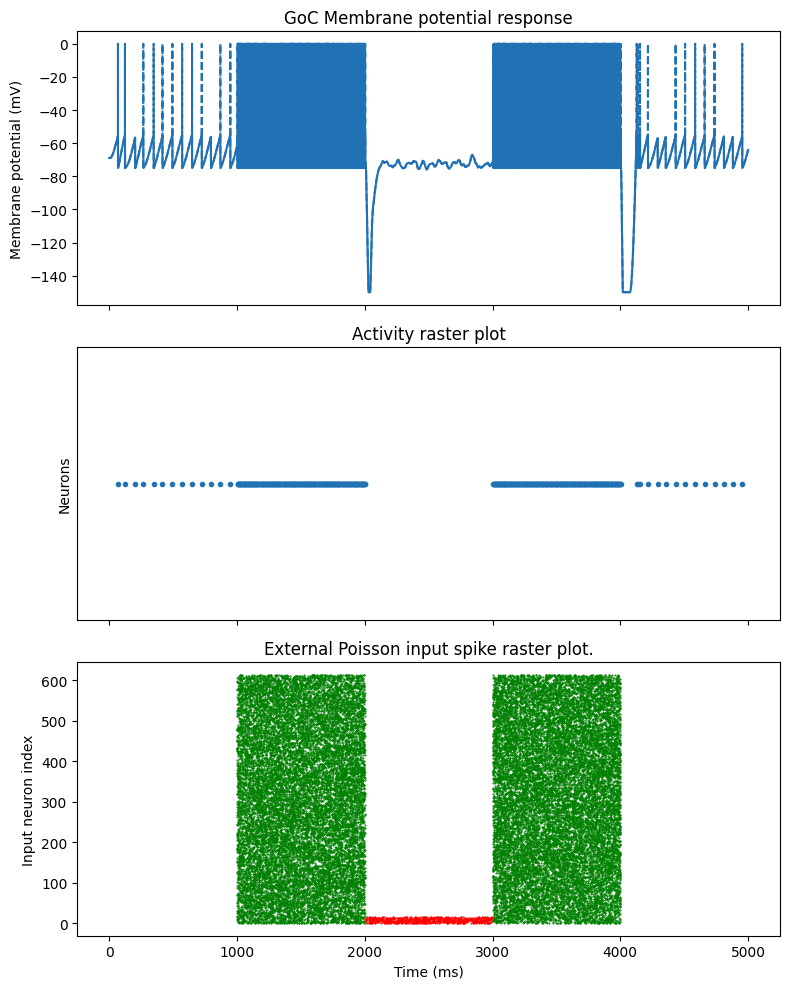

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

mask_PC = (mon_spike_neuron.t >= stim_t_start* b2.ms) & (mon_spike_neuron.t < stim_t_end* b2.ms)
n_spikes_PC_interval = mask_PC.sum() 

v_plot = get_pretty_voltage(mon_neuron.V[0], -56)


ax[0].plot(mon_neuron.t / b2.ms, mon_neuron.V[0] / b2.mV, color=color_palette['GoC'])
ax[0].plot(mon_neuron.t / b2.ms, v_plot / b2.mV, '--', color=color_palette[neuron_model])
ax[0].set_ylabel('Membrane potential (mV)')
ax[0].set_title('GoC Membrane potential response')

ax[1].plot(mon_spike_neuron.t / b2.ms,  np.zeros(len(mon_spike_neuron.t)), '.', color=color_palette['GoC'])
ax[1].set_yticks([]) 
ax[1].set_ylim(-1,1)
ax[1].set_ylabel('Neurons')
ax[1].set_title('Activity raster plot')

ax[2].plot(mon_Poisson_input_inhibition.t / b2.ms, mon_Poisson_input_inhibition.i, '.r', markersize=1)
ax[2].plot(mon_Poisson_input_excitation.t / b2.ms, mon_Poisson_input_excitation.i, '.g', markersize=1)

ax[2].set_xlabel('Time (ms)')
ax[2].set_ylabel('Input neuron index')
ax[2].set_title('External Poisson input spike raster plot.')
plt.tight_layout()
figs.append(fig)

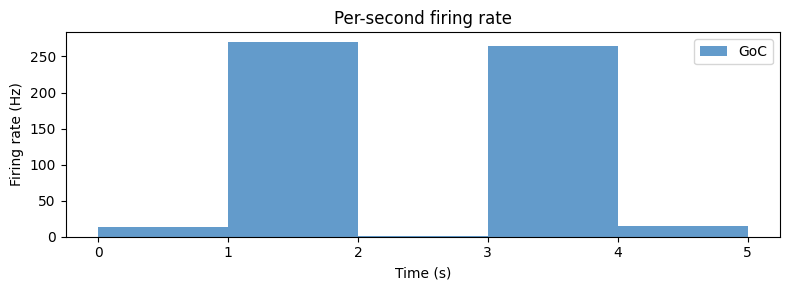

In [18]:
# Convert spike times to seconds
spike_times_neuron = mon_spike_neuron.t / b2.second


# Bin edges: one bin per second
bin_edges = np.arange(0, sim_duration / b2.second + 1, 1.0)

# Histogram: count spikes in each 1-second bin
spikes_per_bin_neuron, _ = np.histogram(spike_times_neuron, bins=bin_edges)

# Firing rate = spikes per second = Hz
firing_rate_per_second_neuron = spikes_per_bin_neuron / 1.0  

# Plotting overlapping histograms
fig, ax = plt.subplots(1, 1, figsize=(8, 3), sharex=True)

ax.bar(np.arange(len(firing_rate_per_second_neuron)), firing_rate_per_second_neuron, width=1.0, align='edge', color = color_palette['GoC'], alpha = 0.7, label=str(neuron_model))

ax.set_xlabel('Time (s)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title('Per-second firing rate')
plt.tight_layout()
plt.legend()
figs.append(fig)

In [19]:
if saving_plots == True:
    save_figs(fig_path, fig_name, figs)